Chapter 5 Bonus: Pretraining Llama 3 on Unlabeled Data

In [ ]:
# 中文说明：本 notebook 用 Llama 3.2(1B)的模型架构，复现第5章“从零预训练一个语言模型”的完整流程——
# 即：随机初始化 Llama 3.2 结构的参数，再在小说《The Verdict》上从头训练，而不是加载 Meta 官方发布的预训练权重。
# 下面先检查所需第三方库的版本
from importlib.metadata import version

pkgs = [
    "matplotlib",
    "numpy",
    "tiktoken",
    "torch",
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")

5.1 Evaluating generative text models
No code


5.1.1 Using Llama 3 to generate text

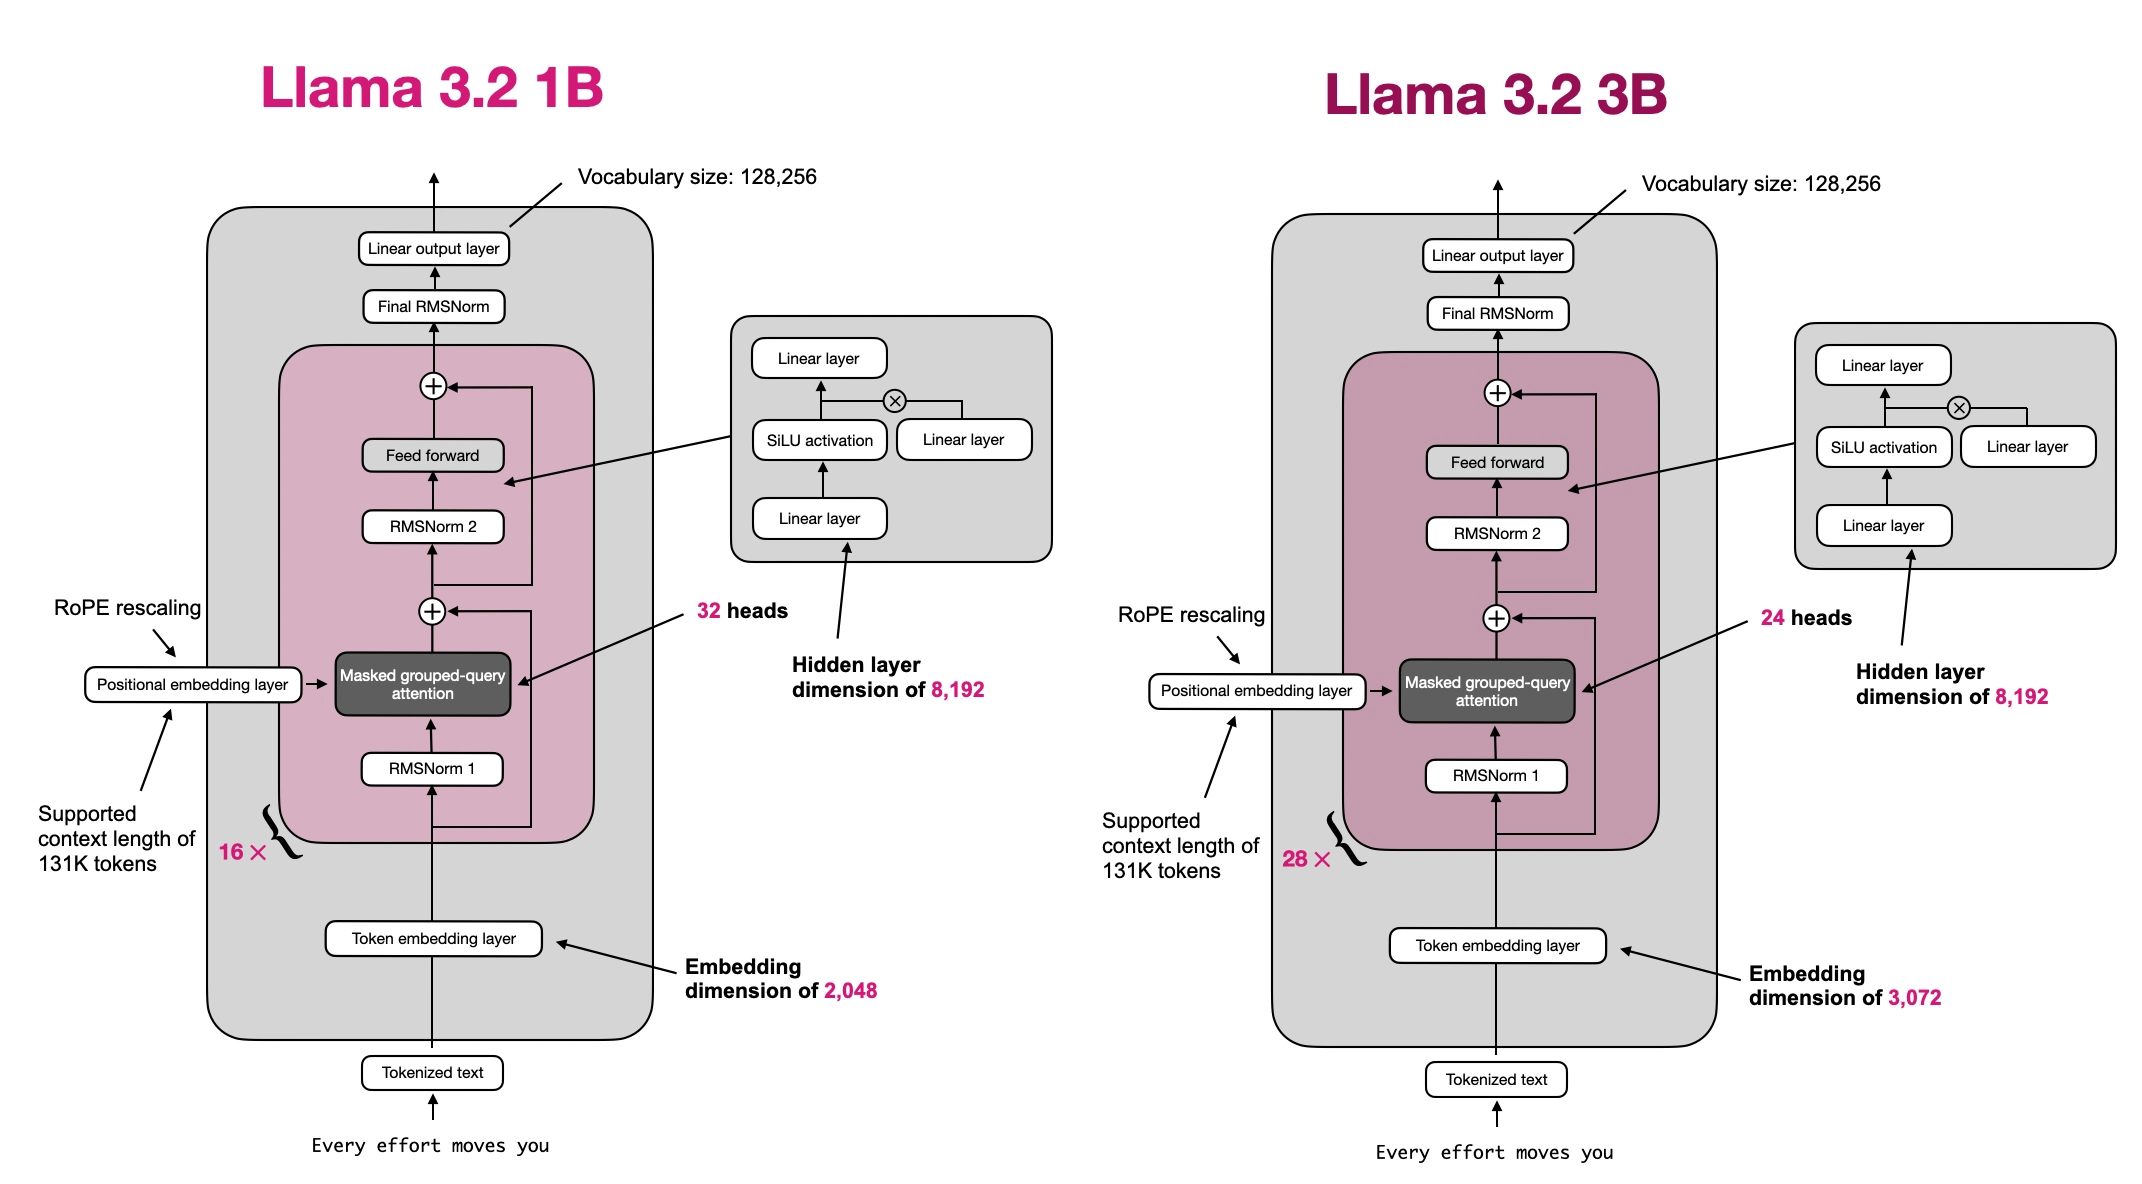

In [ ]:
######################
### Llama 3 Code
######################
# 中文说明：以下代码定义了 Llama 3(此处具体为 Llama 3.2 1B)模型的核心组件，
# 包括 SwiGLU 前馈网络、RoPE 旋转位置编码、分组查询注意力(GQA)、
# Transformer Block 以及完整的 Llama3Model，用于替换第5章中的 GPT 模型结构。
import torch
import torch.nn as nn


# 中文说明：Llama 3 使用 SwiGLU 前馈网络(而不是 GPT 的 GELU MLP)，
# 包含两个并行的线性层 fc1/fc2 做门控，再经 fc3 投影回嵌入维度；所有线性层均无偏置(bias=False)
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc1 = nn.Linear(cfg["emb_dim"], cfg["hidden_dim"], dtype=cfg["dtype"], bias=False)
        self.fc2 = nn.Linear(cfg["emb_dim"], cfg["hidden_dim"], dtype=cfg["dtype"], bias=False)
        self.fc3 = nn.Linear(cfg["hidden_dim"], cfg["emb_dim"], dtype=cfg["dtype"], bias=False)

    def forward(self, x):
        x_fc1 = self.fc1(x)
        x_fc2 = self.fc2(x)
        # 中文说明：SwiGLU 激活 = SiLU(fc1(x)) * fc2(x)，逐元素相乘实现门控机制
        x = nn.functional.silu(x_fc1) * x_fc2
        return self.fc3(x)


# 中文说明：预计算 RoPE(旋转位置编码)所需的 cos/sin 表。
# Llama 3.1/3.2 在原始 RoPE 基础上加入了频率缩放(freq_config)，
# 用于将模型从预训练时的短上下文(如8192)外推到更长的上下文长度(如131072)
def compute_rope_params(head_dim, theta_base=10_000, context_length=4096, freq_config=None, dtype=torch.float32):
    assert head_dim % 2 == 0, "Embedding dimension must be even"

    # Compute the inverse frequencies
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, head_dim, 2, dtype=dtype)[: (head_dim // 2)].float() / head_dim))
    # 中文说明：inv_freq 即标准 RoPE 中的 theta_i = base^(-2i/d)，i 取偶数索引

    # Frequency adjustments
    if freq_config is not None:
        # 中文说明：这里实现的是 Llama 3.1/3.2 的 RoPE 频率缩放(NTK-aware 式插值)，
        # 按波长把频率分为低频/高频/中间频段并分别做不同程度的缩放，以支持长上下文外推
        low_freq_wavelen = freq_config["original_context_length"] / freq_config["low_freq_factor"]
        high_freq_wavelen = freq_config["original_context_length"] / freq_config["high_freq_factor"]

        wavelen = 2 * torch.pi / inv_freq

        inv_freq_llama = torch.where(
            wavelen > low_freq_wavelen, inv_freq / freq_config["factor"], inv_freq
        )

        smooth_factor = (freq_config["original_context_length"] / wavelen - freq_config["low_freq_factor"]) / (
            freq_config["high_freq_factor"] - freq_config["low_freq_factor"]
        )

        smoothed_inv_freq = (
            (1 - smooth_factor) * (inv_freq / freq_config["factor"]) + smooth_factor * inv_freq
        )

        is_medium_freq = (wavelen <= low_freq_wavelen) & (wavelen >= high_freq_wavelen)
        inv_freq_llama = torch.where(is_medium_freq, smoothed_inv_freq, inv_freq_llama)
        inv_freq = inv_freq_llama

    # Generate position indices
    positions = torch.arange(context_length, dtype=dtype)

    # Compute the angles
    angles = positions.unsqueeze(1) * inv_freq.unsqueeze(0)  # Shape: (context_length, head_dim // 2)

    # Expand angles to match the head_dim
    angles = torch.cat([angles, angles], dim=1)  # Shape: (context_length, head_dim)

    # Precompute sine and cosine
    cos = torch.cos(angles)
    sin = torch.sin(angles)

    return cos, sin


# 中文说明：将预先算好的 cos/sin 应用到 query/key 上，实现旋转位置编码(RoPE)。
# 采用“旋转一半维度”(rotate_half)的实现方式：把最后一维切成两半，交换并取负后再与 cos/sin 组合
def apply_rope(x, cos, sin):
    # x: (batch_size, num_heads, seq_len, head_dim)
    batch_size, num_heads, seq_len, head_dim = x.shape
    assert head_dim % 2 == 0, "Head dimension must be even"

    # Split x into first half and second half
    x1 = x[..., : head_dim // 2]  # First half
    x2 = x[..., head_dim // 2 :]  # Second half

    # Adjust sin and cos shapes
    cos = cos[:seq_len, :].unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, seq_len, head_dim)
    sin = sin[:seq_len, :].unsqueeze(0).unsqueeze(0)

    # Apply the rotary transformation
    # 中文说明：rotated 相当于把 x 的两半维度做了一次“旋转”，与 cos/sin 相乘组合后即完成 RoPE
    rotated = torch.cat((-x2, x1), dim=-1)
    x_rotated = (x * cos) + (rotated * sin)

    # It's ok to use lower-precision after applying cos and sin rotation
    return x_rotated.to(dtype=x.dtype)


# 中文说明：分组查询注意力(Grouped-Query Attention, GQA)。
# 与多头注意力(MHA)不同，GQA 让多个 query 头共享同一组 key/value 头(num_kv_groups < num_heads)，
# 从而减少 KV 的显存占用和计算量，这是 Llama 2/3 系列相较 GPT 的关键改进之一
class GroupedQueryAttention(nn.Module):
    def __init__(
            self, d_in, d_out, num_heads,
            num_kv_groups,
            dtype=None
        ):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        assert num_heads % num_kv_groups == 0, "num_heads must be divisible by num_kv_groups"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        # 中文说明：head_dim 是每个注意力头的维度，等于 d_out 除以头数

        self.W_key = nn.Linear(d_in, num_kv_groups * self.head_dim, bias=False, dtype=dtype)
        self.W_value = nn.Linear(d_in, num_kv_groups * self.head_dim, bias=False, dtype=dtype)
        self.num_kv_groups = num_kv_groups
        self.group_size = num_heads // num_kv_groups
        # 中文说明：group_size 表示每个 kv 头要被多少个 query 头共享，
        # 例如 32 个 query 头、8 个 kv 组，则 group_size = 4

        self.W_query = nn.Linear(d_in, d_out, bias=False, dtype=dtype)
        self.out_proj = nn.Linear(d_out, d_out, bias=False, dtype=dtype)

    def forward(self, x, mask, cos, sin):
        b, num_tokens, d_in = x.shape

        queries = self.W_query(x)  # Shape: (b, num_tokens, d_out)
        keys = self.W_key(x)  # Shape: (b, num_tokens, num_kv_groups * head_dim)
        values = self.W_value(x)  # Shape: (b, num_tokens, num_kv_groups * head_dim)

        # Reshape queries, keys, and values
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        keys = keys.view(b, num_tokens, self.num_kv_groups, self.head_dim)
        values = values.view(b, num_tokens, self.num_kv_groups, self.head_dim)

        # Transpose keys, values, and queries
        keys = keys.transpose(1, 2)  # Shape: (b, num_kv_groups, num_tokens, head_dim)
        values = values.transpose(1, 2)  # Shape: (b, num_kv_groups, num_tokens, head_dim)
        queries = queries.transpose(1, 2)  # Shape: (b, num_heads, num_tokens, head_dim)

        # Apply RoPE
        keys = apply_rope(keys, cos, sin)
        queries = apply_rope(queries, cos, sin)
        # 中文说明：只对 query 和 key 施加旋转位置编码，value 不需要旋转

        # Expand keys and values to match the number of heads
        # Shape: (b, num_heads, num_tokens, head_dim)
        keys = keys.repeat_interleave(self.group_size, dim=1)  # Shape: (b, num_heads, num_tokens, head_dim)
        values = values.repeat_interleave(self.group_size, dim=1)  # Shape: (b, num_heads, num_tokens, head_dim)
        # For example, before repeat_interleave along dim=1 (query groups):
        #   [K1, K2]
        # After repeat_interleave (each query group is repeated group_size times):
        #   [K1, K1, K2, K2]
        # If we used regular repeat instead of repeat_interleave, we'd get:
        #   [K1, K2, K1, K2]
        # 中文说明：这里用 repeat_interleave 而不是 repeat，是为了让每个 kv 头被“连续重复”group_size 次，
        # 这样才能与对应的一组 query 头正确对齐(若用 repeat 则会导致头的对应关系错位)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        # Shape: (b, num_heads, num_tokens, num_tokens)
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head
        # 中文说明：计算 query 与 key 的点积注意力分数，形状为 (batch, num_heads, seq_len, seq_len)

        # Compute attention scores
        attn_scores = attn_scores.masked_fill(mask, -torch.inf)
        # 中文说明：用因果掩码(上三角为 True 的位置)把未来位置的注意力分数置为负无穷，实现自回归的因果注意力

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        # 中文说明：注意力分数按 sqrt(head_dim) 缩放后做 softmax 得到注意力权重；
        # 与 GPT 不同，Llama 3 的注意力层中没有使用 dropout
        assert keys.shape[-1] == self.head_dim

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.reshape(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)  # optional projection

        return context_vec


# 中文说明：TransformerBlock 采用 Pre-Norm 结构(用 RMSNorm 而不是 LayerNorm)，
# 依次为：RMSNorm -> GQA 注意力 -> 残差连接 -> RMSNorm -> SwiGLU 前馈 -> 残差连接
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = GroupedQueryAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            num_heads=cfg["n_heads"],
            num_kv_groups=cfg["n_kv_groups"],
            dtype=cfg["dtype"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = nn.RMSNorm(cfg["emb_dim"], eps=1e-5, dtype=cfg["dtype"])
        self.norm2 = nn.RMSNorm(cfg["emb_dim"], eps=1e-5, dtype=cfg["dtype"])

    def forward(self, x, mask, cos, sin):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x, mask, cos, sin)  # Shape [batch_size, num_tokens, emb_size]
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed-forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = x + shortcut  # Add the original input back

        return x


# 中文说明：完整的 Llama3Model，整体结构与第4/5章的 GPTModel 类似(词嵌入 + 多层 TransformerBlock + 输出头)，
# 但没有可学习的位置嵌入层，位置信息改由 RoPE 在注意力层中动态注入，且全程不使用 dropout
class Llama3Model(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # Main model parameters
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"], dtype=cfg["dtype"])
        # 中文说明：与 GPT 不同，这里没有单独的位置嵌入层(nn.Embedding for positions)，
        # 因为位置信息由后面的 RoPE(cos/sin)在注意力计算时提供

        self.trf_blocks = nn.ModuleList(  # ModuleList since Sequential can only accept one input, and we need `x, mask, cos, sin`
            [TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = nn.RMSNorm(cfg["emb_dim"], eps=1e-5, dtype=cfg["dtype"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False, dtype=cfg["dtype"])
        # 中文说明：以下两行(已注释)用于权重绑定(tie embedding 和输出层权重)。
        # Llama 3.2 1B/3B 官方权重默认使用权重绑定，但此处为保持结构简单/独立而未启用

        # Uncomment the following code to tie weights
        # self.out_head.weight = self.tok_emb.weight
        # torch.nn.init.normal_(self.out_head.weight, mean=0.0, std=0.02)

        # Reusable utilities
        cos, sin = compute_rope_params(
            head_dim=cfg["emb_dim"] // cfg["n_heads"],
            theta_base=cfg["rope_base"],
            context_length=cfg["context_length"],
            freq_config=cfg["rope_freq"]
        )
        self.register_buffer("cos", cos, persistent=False)
        self.register_buffer("sin", sin, persistent=False)
        # 中文说明：将 cos/sin 表注册为 buffer(而非 Parameter)，这样会随 .to(device) 一起移动，
        # 但不会被优化器更新，也不会被保存进 state_dict(persistent=False)
        self.cfg = cfg


    def forward(self, in_idx):
        # Forward pass
        tok_embeds = self.tok_emb(in_idx)
        x = tok_embeds
        # 中文说明：与 GPT 的 forward 不同，这里不需要额外加位置嵌入(pos_emb)，直接用 token 嵌入作为输入

        num_tokens = x.shape[1]
        mask = torch.triu(torch.ones(num_tokens, num_tokens, device=x.device, dtype=torch.bool), diagonal=1)
        # 中文说明：动态构造上三角因果掩码，形状为 (num_tokens, num_tokens)，
        # 对角线以上(不含对角线)为 True，表示这些位置需要在注意力中被屏蔽

        for block in self.trf_blocks:
            x = block(x, mask, self.cos, self.sin)
        x = self.final_norm(x)
        logits = self.out_head(x.to(self.cfg["dtype"]))
        return logits
#######################
### Initialize Llama 3
#######################
# 中文说明：以下是 Llama 3.2 1B 模型的超参数配置(取自 Meta 官方配置)，
# 用这些超参数实例化上面定义的 Llama3Model

# Llama 3.2 1B

LLAMA32_CONFIG = {
    "vocab_size": 128_256,           # Vocabulary size
    "context_length": 131_072,       # Context length that was used to train the model
    "emb_dim": 2048,                 # Embedding dimension
    "n_heads": 32,                   # Number of attention heads
    "n_layers": 16,                  # Number of layers
    "hidden_dim": 8192,              # Size of the intermediate dimension in FeedForward
    "n_kv_groups": 8,                # Key-Value groups for grouped-query attention
    "rope_base": 500_000.0,          # The base in RoPE's "theta"
    "dtype": torch.bfloat16,         # Lower-precision dtype to reduce memory usage
    "rope_freq": {                   # RoPE frequency scaling
        "factor": 32.0,
        "low_freq_factor": 1.0,
        "high_freq_factor": 4.0,
        "original_context_length": 8192,
    }
}
# 中文说明：rope_freq 中的四个参数用于 Llama 3.1/3.2 的 RoPE 频率缩放(NTK-aware 式插值)，
# 使原本基于 8192 上下文训练得到的旋转编码能够外推支持到 131072 的上下文长度

LLAMA32_CONFIG["train_context_length"] = 256  # It's a small dataset, and we also want to keep memory usage reasonable
# 中文说明：这里只用《The Verdict》这样的小数据集做演示性预训练，
# 因此把训练时实际使用的上下文长度覆盖为较小的 256(而非模型原生支持的 131072)，以节省显存和计算量

torch.manual_seed(123)
model = Llama3Model(LLAMA32_CONFIG)
model.eval();
#######################
### Set up tokenizer
#######################
# 中文说明：Llama 3 使用基于 tiktoken 的自定义 BPE 分词器(而不是 GPT-2 的分词器)，
# 词表更大(128256)，并包含若干特殊标记(如 <|begin_of_text|>、<|eot_id|> 等)

import os
from pathlib import Path

import tiktoken
from tiktoken.load import load_tiktoken_bpe



class Tokenizer:
    """Thin wrapper around tiktoken that keeps track of Llama-3 special IDs."""
    def __init__(self, model_path):
        if not os.path.isfile(model_path):
            raise FileNotFoundError(model_path)

        mergeable = load_tiktoken_bpe(model_path)
        # 中文说明：加载 Llama 3 官方 tokenizer.model 文件中的 BPE 合并规则表

        # hard-coded from Meta's tokenizer.json
        self.special = {
            "<|begin_of_text|>": 128000,
            "<|end_of_text|>": 128001,
            "<|start_header_id|>": 128006,
            "<|end_header_id|>": 128007,
            "<|eot_id|>": 128009,
        }
        # 中文说明：以上是 Llama 3 分词器中最常用的几个特殊标记及其固定 token ID
        self.special.update({f"<|reserved_{i}|>": 128002 + i
                             for i in range(256)
                             if 128002 + i not in self.special.values()})
        # 中文说明：为词表中尚未被占用的 ID 批量注册 <|reserved_i|> 占位特殊标记，
        # 凑齐 Llama 3 分词器完整的特殊标记集合

        self.model = tiktoken.Encoding(
            name=Path(model_path).name,
            pat_str=r"(?i:'s|'t|'re|'ve|'m|'ll|'d)"
                    r"|[^\r\n\p{L}\p{N}]?\p{L}+"
                    r"|\p{N}{1,3}"
                    r"| ?[^\s\p{L}\p{N}]+[\r\n]*"
                    r"|\s*[\r\n]+"
                    r"|\s+(?!\S)"
                    r"|\s+",
            mergeable_ranks=mergeable,
            special_tokens=self.special,
        )
        # 中文说明：pat_str 是用于切分文本的正则表达式(思路与 GPT-2 版 tiktoken 的切分规则类似)，
        # mergeable_ranks 是 BPE 合并表，special_tokens 是上面定义的特殊标记集合

    def encode(self, text, bos=False, eos=False):
        # 中文说明：encode 将文本转为 token id 列表，可选择性地加上开始符(bos)和结束符(eos)
        ids = ([self.special["<|begin_of_text|>"]] if bos else []) \
              + self.model.encode(text)
        if eos:
            ids.append(self.special["<|end_of_text|>"])
        return ids

    def decode(self, ids):
        return self.model.decode(ids)

In [ ]:
# Uncomment and run the following code if you are executing the notebook for the first time
# 中文说明：Llama 3.2 在 Hugging Face 上是受限(gated)模型，首次运行前需要先用 huggingface_hub 登录，
# 并在 HF 官网申请该模型的访问权限，才能成功下载 tokenizer.model 等文件

#from huggingface_hub import login
#login()
from huggingface_hub import hf_hub_download

# 中文说明：从 Hugging Face Hub 下载 Llama-3.2-1B-Instruct 仓库中的原始 tokenizer.model 文件到本地目录
tokenizer_file_path = hf_hub_download(
    repo_id="meta-llama/Llama-3.2-1B-Instruct",
    filename="original/tokenizer.model",
    local_dir="Llama-3.2-1B-Instruct"
)
tokenizer = Tokenizer(tokenizer_file_path)
# 中文说明：用刚下载好的 tokenizer.model 文件实例化前面定义的 Tokenizer 类
# Same as chapter 4

# 中文说明：文本生成函数与第4/5章完全相同：每一步只取最后一个 token 的 logits，
# 贪心选取概率最大的下一个 token(greedy decoding)
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (B, T) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_token, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Get the idx of the vocab entry with the highest logits value
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx


# 中文说明：文本 <-> token id 的转换工具函数，逻辑与第5章相同，只是这里换成了 Llama 3 的分词器
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text)
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"

# 中文说明：此时的 Llama3Model 只是按 Llama 3.2 架构随机初始化的参数，尚未经过任何训练，
# 也没有加载 Meta 官方发布的预训练权重，所以下面生成的文本大概率是无意义的乱码；
# 后续会在《The Verdict》数据集上从头训练它，复现第5章的预训练流程
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=LLAMA32_CONFIG["train_context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

5.1.2 Calculating the text generation loss: cross-entropy and perplexity
Similar to chapter 5


5.1.3 Calculating the training and validation set losses

In [ ]:
# 中文说明：与第2章相同，下载并读取《The Verdict》文本，作为本次从头预训练用的小数据集
import requests

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text_data = response.text
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

In [ ]:
# First 99 characters
# 中文说明：查看文本开头，确认数据加载正确
print(text_data[:99])

In [ ]:
# Last 99 characters
# 中文说明：查看文本结尾，确认数据完整加载
print(text_data[-99:])

In [ ]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
# 中文说明：用 Llama 3 的分词器统计总字符数与总 token 数；
# 注意这里的 token 数量会与第5章用 GPT-2 分词器时不同，因为词表和切分规则不一样

print("Characters:", total_characters)
print("Tokens:", total_tokens)

In [ ]:
# 中文说明：GPTDatasetV1 和 create_dataloader_v1 与第2/5章完全一致，
# 只是这里传入的 tokenizer 换成了 Llama 3 的 Tokenizer 实例，其 encode 方法用法与原来兼容
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt)

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

# Note that we have to change the function below because we previously hard-coded the
# GPT-2 tokenizer in the data loader
# 中文说明：因为 tokenizer 现在是外部传入的 Llama Tokenizer 实例(而非写死的 GPT-2 编码器)，
# 所以函数内部直接复用传入的 tokenizer 对象
def create_dataloader_v1(txt, tokenizer, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True, num_workers=0):
    # Initialize the tokenizer
    # tokenizer = tiktoken.get_encoding("gpt2")
    tokenizer = tokenizer

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)

    return dataloader


# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

# 中文说明：构建训练集和验证集的 DataLoader；max_length 和 stride 都使用 LLAMA32_CONFIG 中较小的
# train_context_length(256)，而不是模型原生支持的 131072，这样每个训练样本长度可控，适合在小数据集上快速训练
train_loader = create_dataloader_v1(
    train_data,
    tokenizer=tokenizer,
    batch_size=2,
    max_length=LLAMA32_CONFIG["train_context_length"],
    stride=LLAMA32_CONFIG["train_context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    tokenizer=tokenizer,
    batch_size=2,
    max_length=LLAMA32_CONFIG["train_context_length"],
    stride=LLAMA32_CONFIG["train_context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [ ]:
# 中文说明：打印每个 batch 的输入/目标张量形状，确认 DataLoader 按 (batch_size, train_context_length) 组织数据
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

In [ ]:
# 中文说明：统计训练集和验证集中总的 token 数量，了解本次预训练的数据规模
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

In [ ]:
# 中文说明：计算单个 batch 的交叉熵损失，以及对整个 DataLoader 求平均损失，逻辑与第5章完全一致
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [ ]:
# 中文说明：自动选择训练设备；相比第5章原版，这里多了对 Apple Silicon 的 mps 后端支持
# (要求 PyTorch >= 2.9 以保证数值稳定)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")


print(f"Using {device} device.")


model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes


torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

# 中文说明：在正式训练前先评估一次随机初始化模型的损失，作为后续训练效果的基准对比
with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

5.2 Training an LLM

In [ ]:
# 中文说明：训练主循环，与第5章的 train_model_simple 完全相同：每个 batch 做前向、反向传播和参数更新，
# 并按 eval_freq 定期评估训练/验证损失、在每个 epoch 结束后打印生成样例
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


# 中文说明：evaluate_model 只用少量 batch(eval_iter)快速估算当前训练/验证损失，
# 避免每次评估都要跑完整个验证集，从而节省时间
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


# 中文说明：每个 epoch 结束后生成一段样例文本，直观观察模型当前的学习效果
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.cfg["context_length"]
    # 中文说明：这里用的是模型完整的上下文长度(131072)而不是训练时的 train_context_length(256)，
    # 因为 generate_text_simple 只会裁剪超过 context_size 的部分，起始文本很短，实际不会被裁剪，
    # 所以直接使用模型支持的最大上下文长度也没有问题
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()
# Note:
# Uncomment the following code to calculate the execution time
# import time
# start_time = time.time()

# 中文说明：重新以相同随机种子初始化一个全新的 Llama3Model(参数是随机的，
# 与前面测试生成时用的模型不共享权重)，然后用 AdamW 优化器在《The Verdict》上训练 40 个 epoch，
# 复现第5章“从零预训练”的流程，只是模型换成了 Llama 3.2 架构
torch.manual_seed(123)
model = Llama3Model(LLAMA32_CONFIG)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 40
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

# Note:
# Uncomment the following code to show the execution time
# end_time = time.time()
# execution_time_minutes = (end_time - start_time) / 60
# print(f"Training completed in {execution_time_minutes:.2f} minutes.")

5.3 Decoding strategies to control randomness

In [ ]:
# 中文说明：训练结束后，把模型移到 CPU 上做推理生成，使用训练时的上下文长度(256)作为生成时的上下文窗口
inference_device = torch.device("cpu")

model.to(inference_device)
model.eval()

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
    max_new_tokens=25,
    context_size=LLAMA32_CONFIG["train_context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

In [ ]:
# 中文说明：换一个不同的起始提示词 "Hello" 再测试一次生成效果
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Hello", tokenizer).to(inference_device),
    max_new_tokens=25,
    context_size=LLAMA32_CONFIG["train_context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))